# Financial Sentiment Analysis & Price Correlation
This notebook demonstrates:
1. Training a baseline sentiment classifier (Logistic Regression) on the Kaggle Financial PhraseBank.
2. Evaluating a fine-tuned financial model (FinBERT) on the same dataset.
3. Correlating sentiment of recent news with recent stock price movements using Yahoo Finance (`yfinance`).
4. Ticker Analysis.
5. Multi-ticker Sentiment vs. Price Correlation.

In [52]:
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from transformers import pipeline
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

## 1. Load and Prepare the Financial PhraseBank Dataset

In [53]:
# The dataset has two columns, sentiment and sentence, without headers.
df = pd.read_csv('all-data.csv', names=['sentiment', 'sentence'], encoding='latin-1')
print(f"Dataset size: {df.shape}")
display(df.head())

Dataset size: (4846, 2)


,sentiment,sentence
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...


## 2. Exploratory Data Analysis (EDA)
Before building any models, let's understand the data: class distribution, sentence lengths, and the most common words per sentiment class.

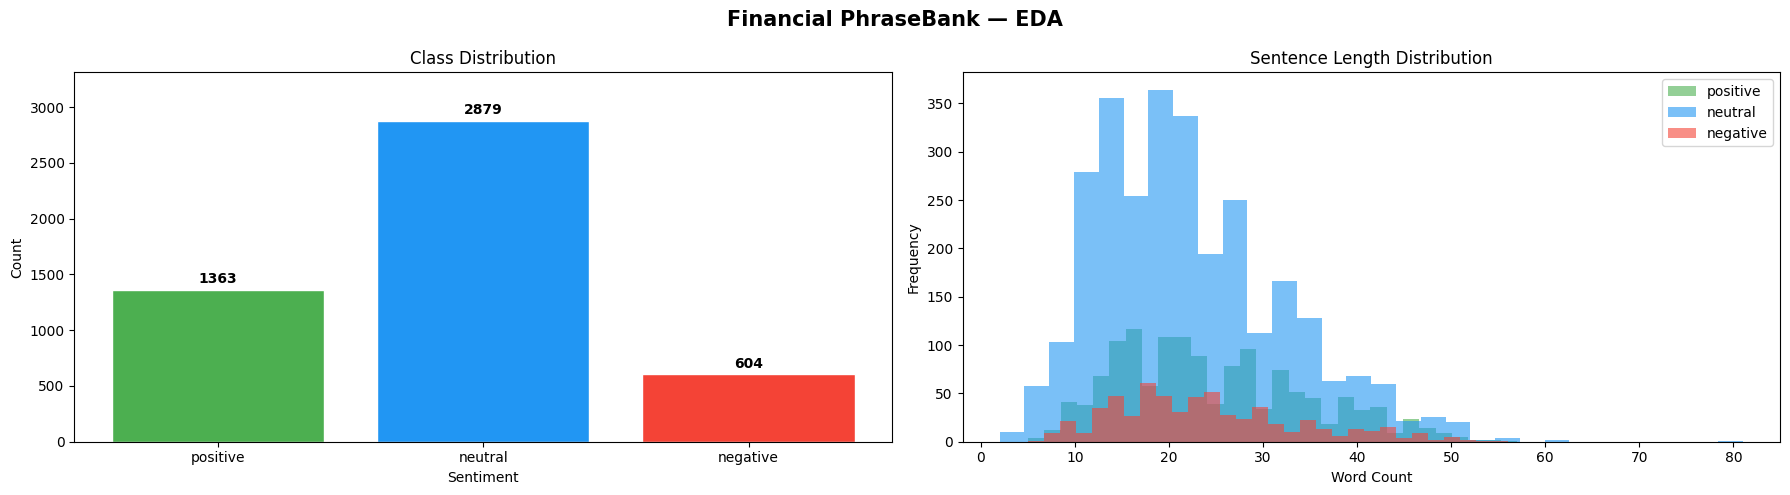

In [ ]:
PALETTE = {'positive': '#4caf50', 'neutral': '#2196f3', 'negative': '#f44336'}

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Financial PhraseBank — EDA', fontsize=15, fontweight='bold')

#sentiment distribution
class_counts = df['sentiment'].value_counts().reindex(['positive', 'neutral', 'negative'])
bars = axes[0].bar(class_counts.index, class_counts.values,
                   color=[PALETTE[c] for c in class_counts.index], edgecolor='white')
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                 str(val), ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, class_counts.max() * 1.15)

#Sentence Length Distribution ---
df['length'] = df['sentence'].str.split().str.len()
for sentiment in ['positive', 'neutral', 'negative']:
    subset = df[df['sentiment'] == sentiment]['length']
    axes[1].hist(subset, bins=30, alpha=0.6, label=sentiment, color=PALETTE[sentiment])
axes[1].set_title('Sentence Length Distribution')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()


plt.tight_layout()
plt.show()
df.drop(columns=['length'], inplace=True)

## 3. Bag-of-Words Baseline (Logistic Regression)

In [57]:
X_train, X_test, y_train, y_test = train_test_split(df['sentence'], df['sentiment'], test_size=0.2, random_state=42)

vectorizer = CountVectorizer(stop_words='english', max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_vec, y_train)

y_pred_base = clf.predict(X_test_vec)
print("Baseline Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_base))
print(classification_report(y_test, y_pred_base))

Baseline Logistic Regression Accuracy: 0.7639175257731958
              precision    recall  f1-score   support

    negative       0.76      0.50      0.60       110
     neutral       0.78      0.91      0.84       571
    positive       0.72      0.58      0.64       289

    accuracy                           0.76       970
   macro avg       0.75      0.66      0.70       970
weighted avg       0.76      0.76      0.75       970



### Baseline Confusion Matrix

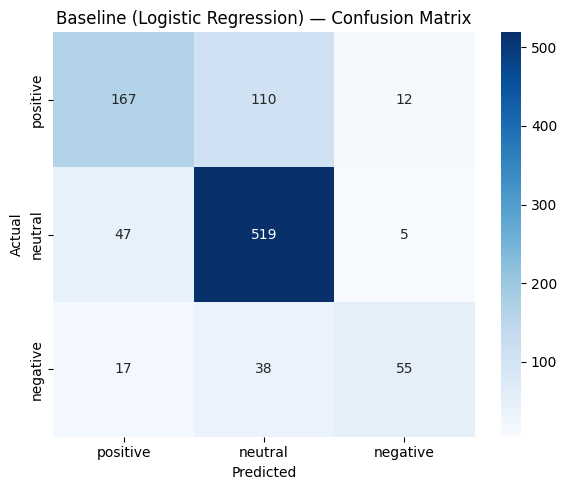

In [58]:
LABELS = ['positive', 'neutral', 'negative']
cm_base = confusion_matrix(y_test, y_pred_base, labels=LABELS)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS, yticklabels=LABELS, ax=ax)
ax.set_title('Baseline (Logistic Regression) — Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

## 4. FinBERT Evaluation
We will use `ProsusAI/finbert`, a BERT model specifically fine-tuned for financial sentiment analysis.

In [ ]:
# Load FinBERT
finbert = pipeline("sentiment-analysis", model="ProsusAI/finbert", device = 'cuda')

# Map FinBERT output to our dataset's labels (neutral, positive, negative)
# To save time in this demonstration, we'll evaluate on a subset of the test data (e.g., 200 samples)
sample_X_test = X_test.sample(200, random_state=42)
sample_y_test = y_test.loc[sample_X_test.index]

finbert_raw = finbert(sample_X_test.tolist())
finbert_preds = [p['label'] for p in finbert_raw]

print("FinBERT Accuracy (on subset):", accuracy_score(sample_y_test, finbert_preds))
print(classification_report(sample_y_test, finbert_preds))

FinBERT Accuracy (on subset): 0.895
              precision    recall  f1-score   support

    negative       0.83      1.00      0.91        24
     neutral       0.98      0.86      0.91       118
    positive       0.79      0.93      0.86        58

    accuracy                           0.90       200
   macro avg       0.87      0.93      0.89       200
weighted avg       0.91      0.90      0.90       200



### FinBERT Confusion Matrix

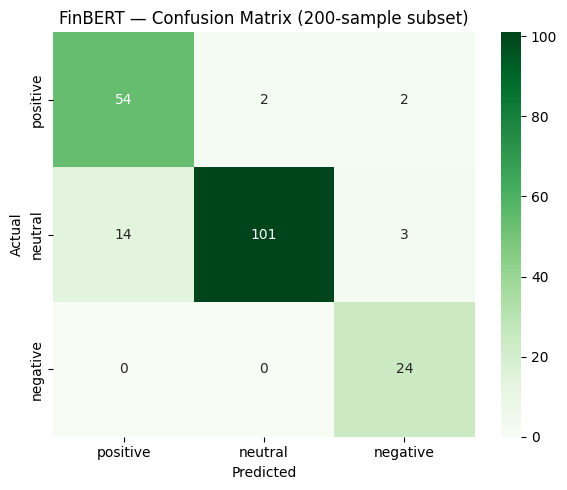

In [62]:
LABELS = ['positive', 'neutral', 'negative']
cm_finbert = confusion_matrix(sample_y_test, finbert_preds, labels=LABELS)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_finbert, annot=True, fmt='d', cmap='Greens',
            xticklabels=LABELS, yticklabels=LABELS, ax=ax)
ax.set_title('FinBERT — Confusion Matrix (200-sample subset)')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

## 4. Ticker Analysis
Set a ticker symbol below to fetch recent news, predict their sentiment using FinBERT, and view the average sentiment alongside the most recent daily price change.

-yfinance has news limit of 10 due to API limitations

Fetching data for AAPL...
Found 10 news on AAPL
AAPL had recent stock price change of -0.8%


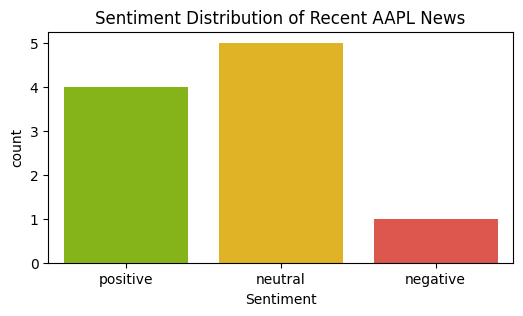

In [72]:
# Set ticker symbol
ticker_symbol = 'AAPL'
print(f"Fetching data for {ticker_symbol}...")

ticker = yf.Ticker(ticker_symbol)
news = ticker.news
print(f'Found {len(news)} news on {ticker_symbol}')
if not news:
    print(f"No recent news found for {ticker_symbol}")
else:
    titles = [n['content']['summary'] for n in news]
    sentiments = finbert(titles)
    
    # Calculate a simple sentiment score: positive=1, neutral=0, negative=-1
    score_map = {'positive': 1, 'neutral': 0, 'negative': -1}
    scores = [score_map[s['label']] * s['score'] for s in sentiments]
    avg_score = np.mean(scores)
    
    # Get recent price movement (last 5 days)
    hist = ticker.history(period="5d")
    recent_change = 0.0
    if len(hist) >= 2:
        recent_change = (hist['Close'].iloc[-1] - hist['Close'].iloc[-2]) / hist['Close'].iloc[-2] * 100
    

    df_news = pd.DataFrame({
        'Title': titles,
        'Sentiment': [s['label'] for s in sentiments],
        'Confidence': [s['score'] for s in sentiments]
    })
    
    # Color coding rows based on sentiment
    def color_sentiment(val):
        color = '#8fce00' if val == 'positive' else '#f44336' if val == 'negative' else '#ffc107'
        return f'color: {color}'

    # Sentiment Distribution Chart
    fig, ax = plt.subplots(figsize=(6, 3))
    sns.countplot(data=df_news, x='Sentiment', order=['positive', 'neutral', 'negative'], 
                  palette={'positive': '#8fce00', 'neutral': '#ffc107', 'negative': '#f44336'}, ax=ax)
    ax.set_title(f'Sentiment Distribution of Recent {ticker_symbol} News')

    print(f'{ticker_symbol} had recent stock price change of {round(recent_change,2)}%')
    plt.show()


## 5. Multi-Ticker Sentiment vs. Price Correlation
Run FinBERT on recent news for a basket of tickers and plot average sentiment score against 10-day price change to explore whether news sentiment correlates with short-term price movement.

In [73]:
TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NVDA', 'JPM', 'V', 'JNJ']

results = []
for sym in TICKERS:
    try:
        t = yf.Ticker(sym)
        news = t.news
        if not news:
            continue
        summaries = []
        for n in news:
            try:
                summaries.append(n['content']['summary'])
            except (KeyError):
                pass
        if not summaries:
            continue

        preds = finbert(summaries)
        score_map = {'positive': 1, 'neutral': 0, 'negative': -1}
        avg_sent = np.mean([score_map[p['label']] * p['score'] for p in preds])

        hist = t.history(period='10d')
        if len(hist) < 2:
            continue
        
        price_chg = (hist['Close'].iloc[-1] - hist['Close'].iloc[0]) / hist['Close'].iloc[0] * 100

        results.append({'Ticker': sym, 'Avg Sentiment': avg_sent, 'Price Change (10d %)': price_chg})
        print(f"{sym}: sentiment={avg_sent:.3f}, price_chg={price_chg:.2f}%")
    except Exception as e:
        print(f"{sym}: skipped ({e})")

corr_df = pd.DataFrame(results)
display(corr_df)

AAPL: sentiment=0.219, price_chg=4.90%
MSFT: sentiment=-0.251, price_chg=2.96%
GOOGL: sentiment=0.088, price_chg=2.19%
AMZN: sentiment=0.063, price_chg=-3.18%
TSLA: sentiment=0.258, price_chg=5.30%
META: sentiment=-0.426, price_chg=1.03%
NVDA: sentiment=0.115, price_chg=13.14%
JPM: sentiment=0.337, price_chg=-2.80%
V: sentiment=0.096, price_chg=3.51%
JNJ: sentiment=0.372, price_chg=1.49%


,Ticker,Avg Sentiment,Price Change (10d %)
0,AAPL,0.219406,4.903370
1,MSFT,-0.250884,2.955905
2,GOOGL,0.087965,2.190873
3,AMZN,0.063003,-3.176751
4,TSLA,0.257802,5.295733
5,META,-0.425574,1.033126
6,NVDA,0.114517,13.139953
7,JPM,0.336553,-2.802192
8,V,0.096300,3.508873
9,JNJ,0.372095,1.494123


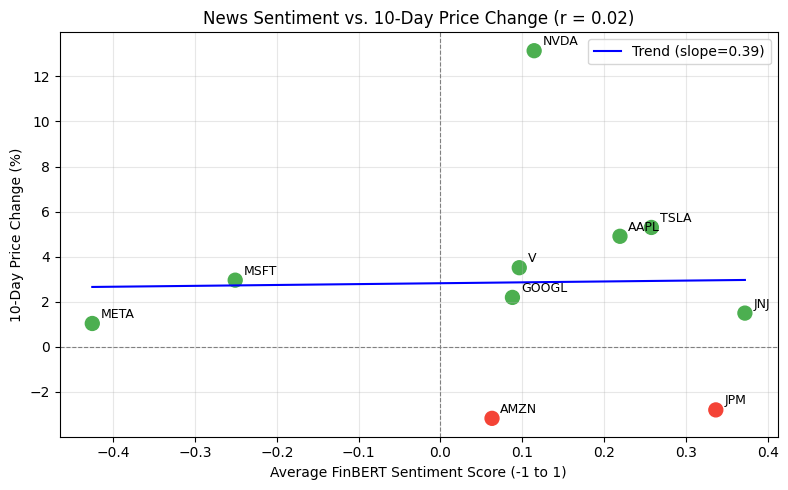

In [78]:
# Scatter plot
if len(corr_df) > 1:
    fig, ax = plt.subplots(figsize=(8, 5))

    #green if >0 red if <0
    colors = corr_df['Price Change (10d %)'].apply(
        lambda x: '#4caf50' if x >= 0 else '#f44336')

    ax.scatter(corr_df['Avg Sentiment'],
                corr_df['Price Change (10d %)'],
                c=colors,
                s=100)

    #label each ticker    
    for _, row in corr_df.iterrows():
        ax.annotate(row['Ticker'],
                    (row['Avg Sentiment'], row['Price Change (10d %)']),
                    textcoords='offset points', xytext=(6, 4), fontsize=9)

            
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')

    #Linear correlation line
    m, b = np.polyfit(corr_df['Avg Sentiment'], corr_df['Price Change (10d %)'], 1)
    x_line = np.linspace(corr_df['Avg Sentiment'].min(), corr_df['Avg Sentiment'].max(), 100)
    ax.plot(x_line, m * x_line + b, color='blue', linewidth=1.5, linestyle='-', label=f'Trend (slope={m:.2f})')
    corr_val = corr_df['Avg Sentiment'].corr(corr_df['Price Change (10d %)'])
    
    ax.set_title(f'News Sentiment vs. 10-Day Price Change (r = {corr_val:.2f})')
    ax.set_xlabel('Average FinBERT Sentiment Score (-1 to 1)')
    ax.set_ylabel('10-Day Price Change (%)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()